# Griffiths Prob 7.11 -- the falling aluminum loop (eddy-current brake)
### a square loop falls out of a B-field; induced currents brake it to terminal velocity

A square loop (side $s$) is cut from a thick aluminum sheet and dropped so its top
edge starts in a uniform field $\mathbf B$ (into the page). As it falls, the flux
through the loop changes, an EMF drives a current, and -- by **Lenz's law** -- the
force on that current OPPOSES the fall. The loop quickly reaches a constant
**terminal velocity**. We derive it, simulate it, and find the surprising result
that for aluminum the terminal speed does not depend on the loop's size.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import electrodynamics as ed
print("ready")

ready


## 1. The physics (one force balance)

The edge in the field moves at speed $v$, so (flux rule) the EMF is $\varepsilon=Bsv$.
That drives a current $I=\varepsilon/R=Bsv/R$, and the field pushes back on that
current with a **retarding** force
$$F_{\text{brake}}=BIs=\frac{B^2s^2}{R}\,v.$$
Newton's second law for the fall is therefore a first-order linear ODE:
$$m\frac{dv}{dt}=mg-\frac{B^2s^2}{R}\,v.$$
Setting $dv/dt=0$ gives the **terminal velocity**
$$\boxed{\,v_t=\frac{mgR}{B^2s^2}\,}.

In [2]:
m, g, R, B, s = 0.01, 9.81, 0.05, 0.5, 0.1     # 10 g loop, 5 cm side region, B=0.5 T
v_t = ed.eddy_brake_terminal_velocity(m, g, R, B, s)
tau = m * R / (B**2 * s**2)
print(f"terminal velocity v_t = mgR/(B^2 s^2) = {v_t:.3f} m/s")
print(f"time constant     tau = mR/(B^2 s^2) = {tau:.3f} s   (= v_t/g)")

terminal velocity v_t = mgR/(B^2 s^2) = 1.962 m/s
time constant     tau = mR/(B^2 s^2) = 0.200 s   (= v_t/g)


## 2. The approach to terminal velocity is exponential

The linear ODE solves to
$$v(t)=v_t+(v_0-v_t)\,e^{-t/\tau},\qquad \tau=\frac{mR}{B^2s^2},$$
the same $e^{-t/\tau}$ shape as an RC capacitor charging. From rest it rises and
levels off at $v_t$.

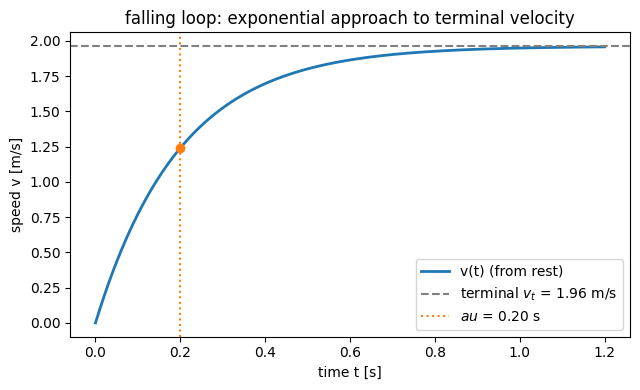

at t=tau the loop is at 63% of v_t (the 1 - 1/e point)


In [3]:
t = np.linspace(0, 6*tau, 600)
v = ed.falling_loop_velocity(m, g, R, B, s, t, v0=0.0)
plt.figure(figsize=(6.5, 4))
plt.plot(t, v, lw=2, label="v(t) (from rest)")
plt.axhline(v_t, ls="--", color="gray", label=f"terminal $v_t$ = {v_t:.2f} m/s")
plt.axvline(tau, ls=":", color="C1", label=f"$\tau$ = {tau:.2f} s")
plt.scatter([tau], [v_t*(1-1/np.e)], color="C1", zorder=5)   # 63% of v_t at t=tau
plt.xlabel("time t [s]"); plt.ylabel("speed v [m/s]")
plt.title("falling loop: exponential approach to terminal velocity"); plt.legend()
plt.tight_layout(); plt.show()
print(f"at t=tau the loop is at {(1-1/np.e)*100:.0f}% of v_t (the 1 - 1/e point)")

## 3. Numerical RK4 matches the analytic curve

The same ODE integrated with Runge-Kutta -- the template you would need if the drag
were nonlinear and had no closed form -- lands right on top of the exponential.

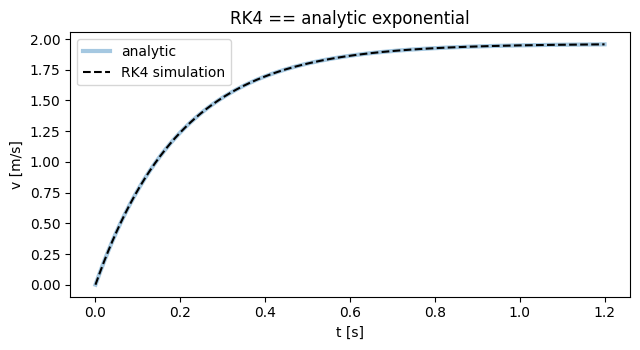

max |RK4 - analytic| = 6.105826955149496e-11


In [4]:
v_num = ed.falling_loop_simulation(m, g, R, B, s, t, v0=0.0)
plt.figure(figsize=(6.5, 3.6))
plt.plot(t, v, lw=3, alpha=0.4, label="analytic")
plt.plot(t, v_num, "--", color="k", label="RK4 simulation")
plt.xlabel("t [s]"); plt.ylabel("v [m/s]"); plt.legend()
plt.title("RK4 == analytic exponential"); plt.tight_layout(); plt.show()
print("max |RK4 - analytic| =", np.max(np.abs(v_num - v)))

## 4. The brake works BOTH ways

Terminal velocity is an attractor. Drop the loop from rest and it speeds *up* to
$v_t$; launch it downward faster than $v_t$ and the brake slows it *down* to the
same $v_t$. Either way the loop ends up coasting at $v_t$.

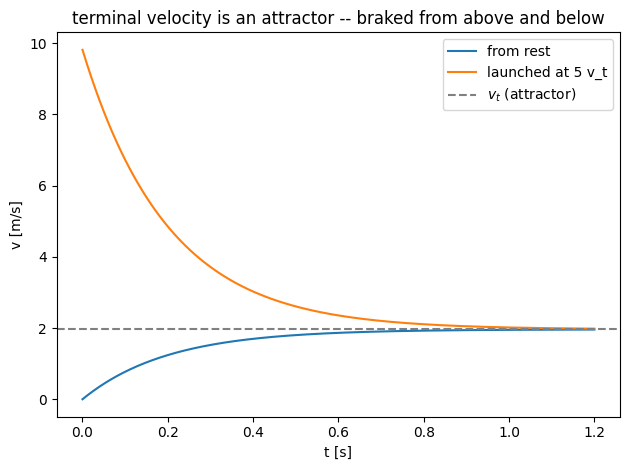

In [5]:
for v0, lbl in [(0.0, "from rest"), (5*v_t, "launched at 5 v_t")]:
    plt.plot(t, ed.falling_loop_simulation(m, g, R, B, s, t, v0=v0), label=lbl)
plt.axhline(v_t, ls="--", color="gray", label="$v_t$ (attractor)")
plt.xlabel("t [s]"); plt.ylabel("v [m/s]"); plt.legend()
plt.title("terminal velocity is an attractor -- braked from above and below")
plt.tight_layout(); plt.show()

## 5. The aluminum punchline -- size doesn't matter

Build the loop from square-section conductor: $m=\rho_m(4s)w^2$ and
$R=\rho_r(4s)/w^2$, so $mR=16\,\rho_m\rho_r s^2$ and the $s^2$ **cancels**:
$$v_t=\frac{16\,\rho_m\,\rho_r\,g}{B^2}\quad(\text{independent of }s\text{ and }w!).$$
A 5 cm loop and a 50 cm loop fall at the *same* speed. And $v_t\propto 1/B^2$, so a
stronger field brakes harder.

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_62864\3572878193.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_title("$v_t \propto 1/B^2$ -- stronger field, harder brake")


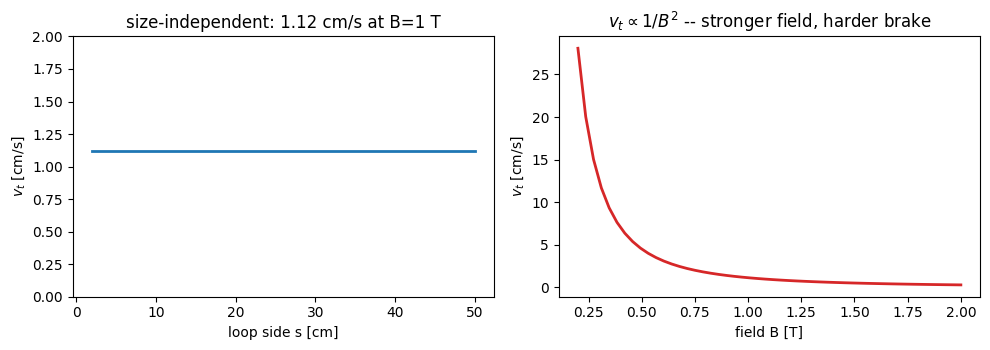

aluminum terminal velocity at 1 T = 1.12 cm/s (any size)


In [6]:
# v_t vs loop size (flat) and vs field strength (1/B^2)
sizes = np.linspace(0.02, 0.5, 50)
vt_alu = ed.aluminum_loop_terminal_velocity(B=1.0)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(sizes*100, np.full_like(sizes, vt_alu)*100, lw=2)
ax[0].set_xlabel("loop side s [cm]"); ax[0].set_ylabel("$v_t$ [cm/s]")
ax[0].set_title(f"size-independent: {vt_alu*100:.2f} cm/s at B=1 T"); ax[0].set_ylim(0, 2)
Bs = np.linspace(0.2, 2.0, 50)
ax[1].plot(Bs, [ed.aluminum_loop_terminal_velocity(B=b)*100 for b in Bs], lw=2, color="C3")
ax[1].set_xlabel("field B [T]"); ax[1].set_ylabel("$v_t$ [cm/s]")
ax[1].set_title("$v_t \propto 1/B^2$ -- stronger field, harder brake")
plt.tight_layout(); plt.show()
print(f"aluminum terminal velocity at 1 T = {vt_alu*100:.2f} cm/s (any size)")

## What 7.11 teaches

1. **Lenz's law is a brake**: induced currents always oppose the change that makes
   them, so the falling loop feels a drag $\propto v$.
2. That gives a linear ODE whose solution is the **exponential** approach to
   $v_t=mgR/(B^2s^2)$ -- terminal velocity is an attractor (braked from both sides).
3. For a uniform aluminum loop the size cancels: $v_t=16\rho_m\rho_r g/B^2\approx
   1\,\text{cm/s}$ at 1 T -- a dramatic, size-independent eddy-current brake.

Same induced-EMF physics as the sliding bar and the AC generator -- one law,
$\varepsilon=-d\Phi/dt$. Civilian education.